In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# add Code folder
import sys
sys.path.append('../../qdarts')

# import main class and plotting function
from experiment import Experiment
from plotting import plot_polytopes

# import standard libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec



## Device definition

In [12]:
# Define the system

#All capacitances are given in aF
N = 3 #number of dots   
C_DD =np.diag(np.random.normal(20, 1,size=N))/2 #The self-capacitance of each dot, NOTE: factor of 2 due to symmetrization
C_DD += np.random.normal(5, 1, size=((N,N)))

C_DD = C_DD + C_DD.T

C_DG = np.diag(np.random.normal(10, 1,size=N))/2 
#cross-capacitances
C_DG += np.random.normal(2, 1, size=((N,N)))

# Definition of the tunnel couplings in eV 
# NOTE: we use the convention that tc is the energy gap at avoided crossing H = tc/2 sx
tunnel_couplings = np.zeros((N,N))
for k in range(N-2):
    tc = np.random.normal(50*1e-6, 10*1e-6)
    tunnel_couplings[k,k+1] = tc
    tunnel_couplings[k+1,k] = tc


In [13]:
capacitance_config = {
        "C_DD" : C_DD,  #dot-dot capacitance matrix
        "C_Dg" : C_DG,  #dot-gate capacitance matrix
        "ks" : None,       #distortion of Coulomb peaks. NOTE: If None -> constant size of Coublomb peak 
}

tunneling_config = {
        "tunnel_couplings": tunnel_couplings, #tunnel coupling matrix
        "temperature": 0.1,                   #temperature in Kelvin
        "energy_range_factor": 2,  #energy scale for the Hamiltonian generation. NOTE: Smaller -> faster but less accurate computation 
}
sensor_config = {
        "sensor_dot_indices": [2],  #Indices of the sensor dots
        "sensor_detunings": [-0.0005],  #Detuning of the sensor dots
        "noise_amplitude": {"fast_noise": 0.8*1e-4, "slow_noise": 1e-6}, #Noise amplitude for the sensor dots in eV
        "peak_width_multiplier": 15,  #Width of the sensor peaks in the units of thermal broadening m *kB*T/0.61.
}


In [14]:
np.save('C_DD.npy', C_DD)
np.save('C_Dg.npy', C_DG)
np.save('tunnel_couplings.npy', tunnel_couplings)

In [15]:
# Create the experiment object from the configuration files
experiment = Experiment(capacitance_config, tunneling_config, sensor_config)

EXPERIMENT INITIALIZED
-----------------------

                Capacitance model deployed with the following parameters:
                Dot-dot capacitances: 
                [[30.95685948  9.75771195  9.26149174]
 [ 9.75771195 28.48714318 10.87179608]
 [ 9.26149174 10.87179608 28.65278671]]
                Dot-gate capacitances: 
                [[ 7.30070373  2.72762715  1.36255999]
 [ 1.59610449  6.65468383  3.34039464]
 [-0.02406249  0.08679257  7.76491483]]
                Size of Coulomb peaks V[n] is constant
                

            Sensor model deployed with the following parameters:   
            Sensor dot indices: [0]
            Sensor detunings: [-0.5] meV
            Coulomb peak width: 0.41 meV
            Slow noise amplitude: 1.0 ueV
            Fast noise amplitude: 80.0 ueV
            

            Tunneling model deployed with the following parameters:
            Tunneling matrix:
            [[0.00000000e+00 4.40726397e-05 0.00000000e+00]
 [4.40726397e-0

In [16]:
xexp, yexp, csd_data, polytopes_data, sensor_signalexp, _ = experiment.generate_CSD(
                                    plane_axes = np.array([[1,0,5],[0,1,0]]), # vectors spanning the cut in voltage space
                                    target_state = [1,1,5],  # target state for transition
                                    target_transition = [1,-1,0],
                                    x_voltages=np.linspace(-0.005, 0.005, 100), #voltage range for x-axis
                                    y_voltages=np.linspace(-0.005, 0.005, 100), #voltage range for y-axis
                                    compute_polytopes = True, #compute the corners of constant occupation
                                    compensate_sensors= True, #compensate the sensor signals
                                    use_virtual_gates= False, #use the virtual gates
                                    use_sensor_signal= True) #use the sensor signals

v_offset found: [-0.04355238  0.10572158]


/Users/krzywdaja/Documents/Science/Science/Projects/QDarts/examples/2dots/../../qdarts/tunneling_simulator.py:116: RuntimeWarning: invalid value encountered in double_scalars
  results[i] = np.sum(p*np.mean(g,axis=1))/np.sum(p)


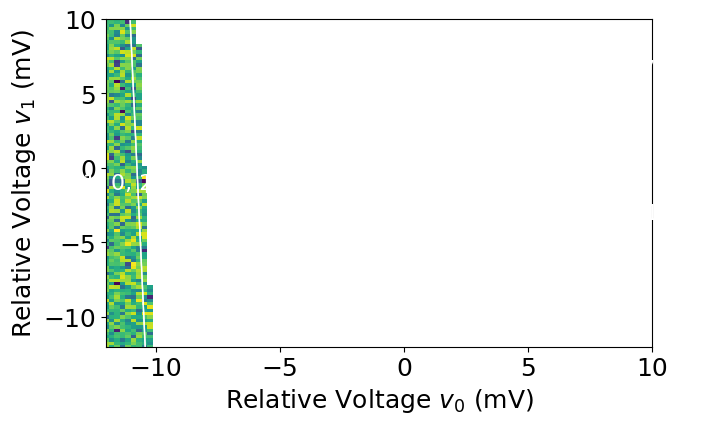

In [19]:
plt.figure(figsize=(6, 4))


# Define the grid
gs = gridspec.GridSpec(1, 1)
plt.subplots_adjust(wspace=0.3, top = 0.98, bottom = 0.16, left = 0.08, right = 0.99)

# Create subplots
ax0 = plt.subplot(gs[0])


#plot the csd with background polytopes
ax0.pcolormesh(1e3*xexp,1e3*yexp,sensor_signalexp[:,:,0]) #plot the background
plot_polytopes(ax0,polytopes_data, axes_rescale = 1e3, skip_dots = [], fontsize=16) #plot the polytopes

# plot customisation
ax0.set_xlabel('Relative Voltage $v_0$ (mV)')
ax0.set_ylabel('Relative Voltage $v_1$ (mV)')
ax0.set_xlim(xexp[0]*1e3,xexp[-1]*1e3)
ax0.set_ylim(yexp[0]*1e3,yexp[-1]*1e3)

# save files
np.save('csd_data.npy', csd_data)
np.save('polytopes_data.npy', polytopes_data)
np.save('x_axis.npy', xexp)
np.save('y_axis.npy', yexp)



